In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('C:\\Users\\santa\\Desktop\\ETL_cositas\\workshop_03\\data\\processed\\happiness_unified.csv')
print(f"Shape: {df.shape}")
display(df.head())

Shape: (782, 11)


,year,country,region,rank,score,gdp,family,health,freedom,generosity,trust
0,2015,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,2015,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,2015,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,2015,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,2015,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [13]:
FEATURES = ['gdp', 'family', 'health', 'freedom', 'generosity', 'trust',]
TARGET   = 'score'

X = df[FEATURES]
y = df[TARGET]

print(f"Features: {FEATURES}")
print(f"Target:   {TARGET}")
print(f"X shape:  {X.shape}")

Features: ['gdp', 'family', 'health', 'freedom', 'generosity', 'trust']
Target:   score
X shape:  (782, 6)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 547 filas
Test:  235 filas


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [16]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Modelo entrenado")

Modelo entrenado


In [17]:
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.4486
RMSE: 0.5843
R²:   0.7265


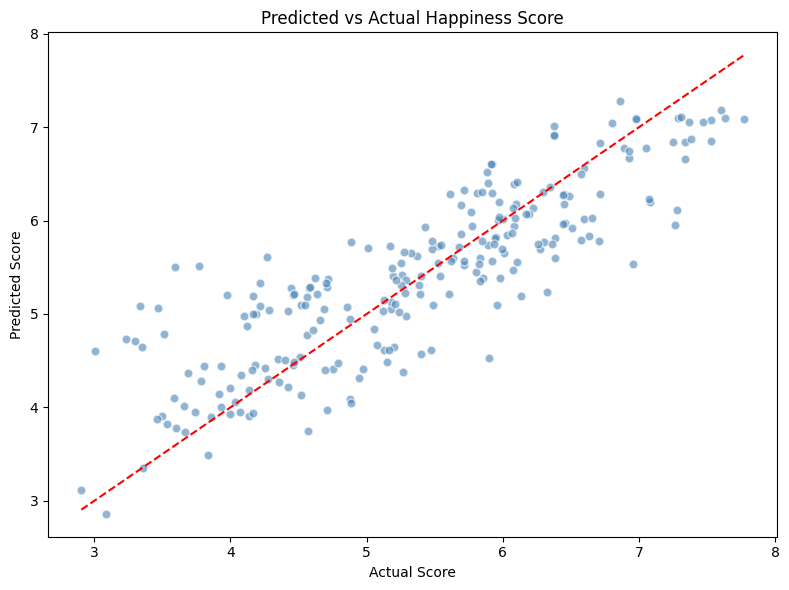

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=40)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Predicted vs Actual Happiness Score')
plt.tight_layout()
plt.show()

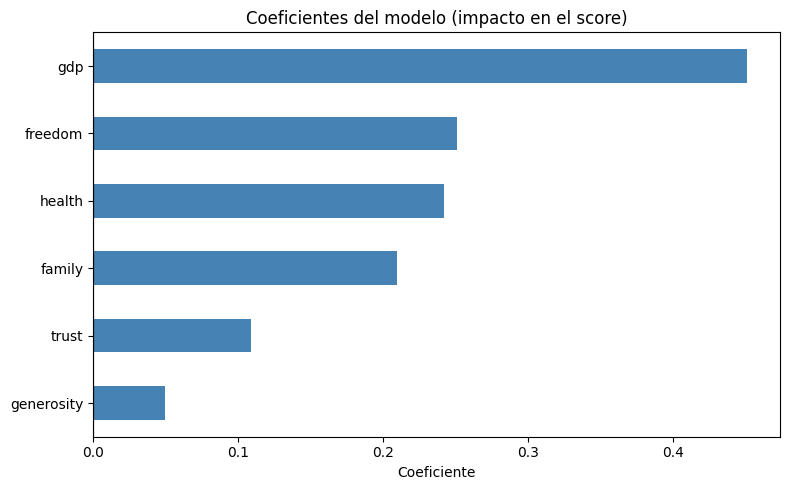

In [19]:
coefs = pd.Series(model.coef_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
coefs.plot(kind='barh', color=['tomato' if c < 0 else 'steelblue' for c in coefs])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del modelo (impacto en el score)')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

In [23]:
with open(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\models\model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\models\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("model.pkl  guardado")
print("scaler.pkl guardado")

model.pkl  guardado
scaler.pkl guardado


In [27]:
test_df = X_test.copy()
test_df['score'] = y_test.values
test_df['year'] = df.loc[X_test.index, 'year']   # ← agregar year
test_df['country'] = df.loc[X_test.index, 'country']  # ← y country también
test_df.to_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\data\streaming\test_set.csv', index=False)